In [1]:
import pandas as pd
# Importar las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
df = pd.read_csv('bank_data.csv', sep=";")

In [3]:

print(df.head())


print(df.info())


print(df.describe())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #

In [4]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [5]:
print(df.duplicated().value_counts())

False    45211
Name: count, dtype: int64


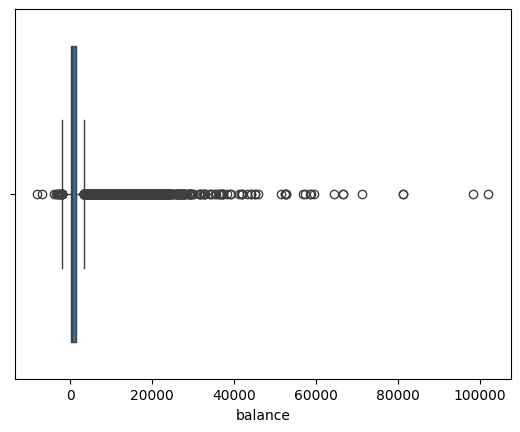

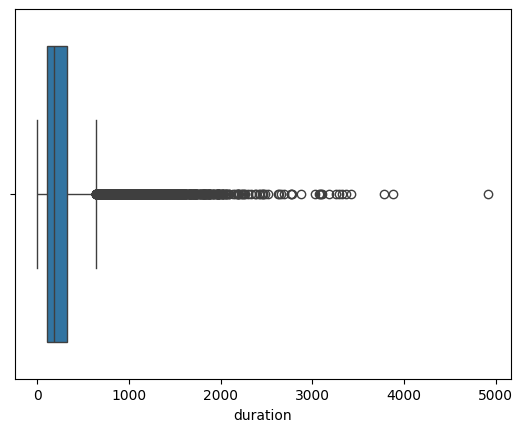

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de distribución para detectar posibles outliers en la columna balance
sns.boxplot(x=df['balance'])
plt.show()

# Gráfico de distribución para la duración de la llamada
sns.boxplot(x=df['duration'])
plt.show()


C:\Users\aleja\AppData\Local\Temp\ipykernel_138156\1713754198.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_counts = df.groupby(['age_group', 'y']).size().unstack(fill_value=0)


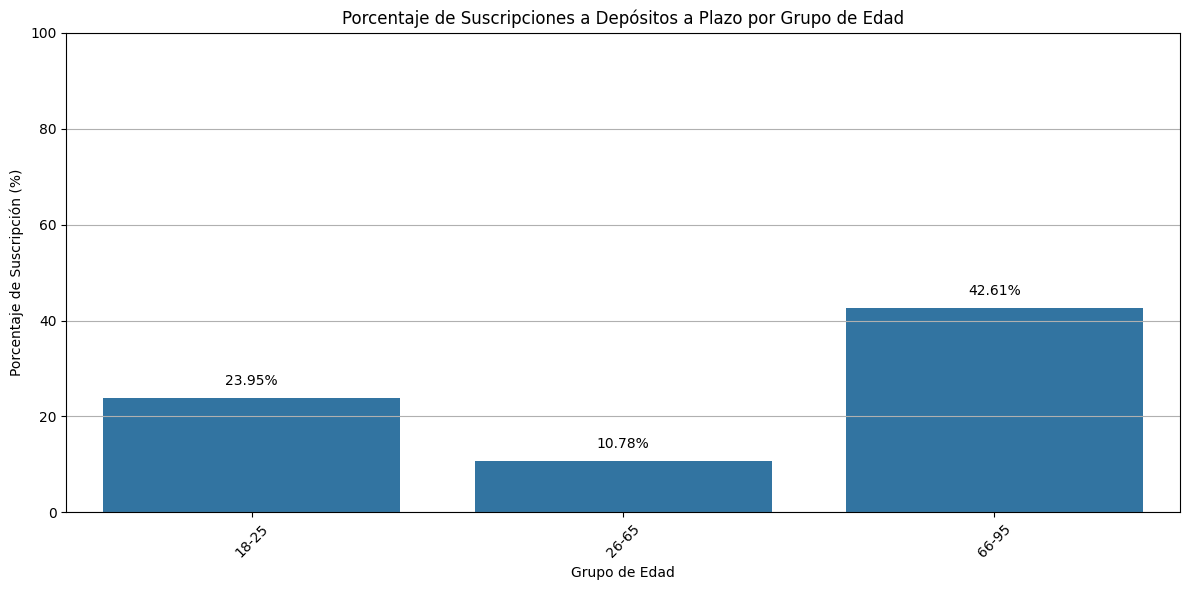

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Convertir la variable objetivo a numérica
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Crear una nueva columna para agrupar por rangos de edad
bins = [18, 26, 66, 96]
labels = ['18-25', '26-65', '66-95']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Calcular el conteo de suscripciones por grupo de edad
age_counts = df.groupby(['age_group', 'y']).size().unstack(fill_value=0)

# Calcular el porcentaje de suscripciones
age_counts['Total'] = age_counts.sum(axis=1)
age_counts['Suscripción (%)'] = (age_counts[1] / age_counts['Total']) * 100

# Crear la gráfica de barras para porcentajes
plt.figure(figsize=(12, 6))
sns.barplot(x=age_counts.index, y=age_counts['Suscripción (%)'])

plt.title('Porcentaje de Suscripciones a Depósitos a Plazo por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Porcentaje de Suscripción (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45)

# Añadir etiquetas de porcentaje encima de las barras
for index, value in enumerate(age_counts['Suscripción (%)']):
    plt.text(index, value + 2, f"{value:.2f}%", ha='center', va='bottom')

plt.grid(axis='y')
plt.tight_layout()
plt.show()


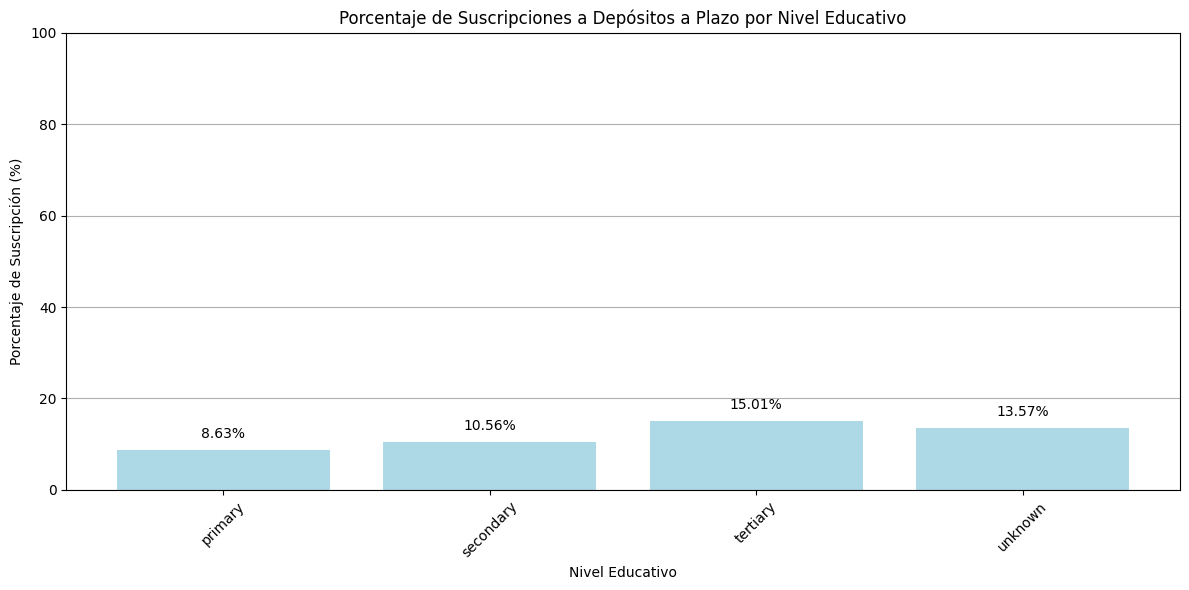

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Convertir la variable objetivo a numérica
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Calcular el conteo de suscripciones por nivel educativo
education_counts = df.groupby(['education', 'y']).size().unstack(fill_value=0)

# Calcular el porcentaje de suscripciones
education_counts['Total'] = education_counts.sum(axis=1)
education_counts['Suscripción (%)'] = (education_counts[1] / education_counts['Total']) * 100

# Crear la gráfica de barras
plt.figure(figsize=(12, 6))
plt.bar(education_counts.index, education_counts['Suscripción (%)'], color='lightblue')

plt.title('Porcentaje de Suscripciones a Depósitos a Plazo por Nivel Educativo')
plt.xlabel('Nivel Educativo')
plt.ylabel('Porcentaje de Suscripción (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.grid(axis='y')

# Añadir etiquetas de porcentaje encima de las barras
for index, value in enumerate(education_counts['Suscripción (%)']):
    plt.text(index, value + 2, f"{value:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()


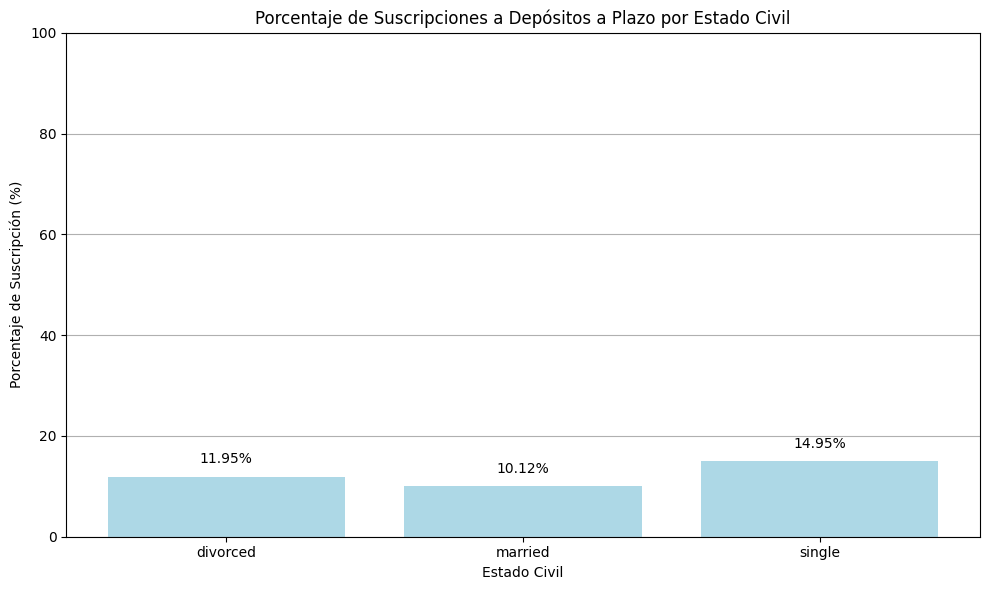

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Convertir la variable objetivo a numérica
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Calcular el conteo de suscripciones por estado civil
marital_counts = df.groupby('marital')['y'].value_counts().unstack(fill_value=0)

# Calcular el porcentaje de suscripciones
marital_counts['Total'] = marital_counts.sum(axis=1)
marital_counts['Suscripción (%)'] = (marital_counts[1] / marital_counts['Total']) * 100

# Crear la gráfica de barras
plt.figure(figsize=(10, 6))
plt.bar(marital_counts.index, marital_counts['Suscripción (%)'], color='lightblue')

plt.title('Porcentaje de Suscripciones a Depósitos a Plazo por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Porcentaje de Suscripción (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.grid(axis='y')

# Añadir etiquetas de porcentaje encima de las barras
for index, value in enumerate(marital_counts['Suscripción (%)']):
    plt.text(index, value + 2, f"{value:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()


## Analisis de Datos

In [12]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


In [13]:
df.describe()



,age,balance,day,duration,campaign,pdays,previous,y
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,0.116985
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


In [14]:
df[['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']].value_counts()


job            marital  education  default  housing  loan  contact    month  poutcome
blue-collar    married  secondary  no       yes      no    unknown    may    unknown     750
management     married  tertiary   no       no       no    cellular   aug    unknown     705
blue-collar    married  primary    no       yes      no    unknown    may    unknown     657
technician     married  secondary  no       no       no    cellular   aug    unknown     439
management     single   tertiary   no       no       no    cellular   aug    unknown     385
                                                                                        ... 
self-employed  married  tertiary   no       yes      yes   cellular   apr    failure       1
entrepreneur   married  tertiary   no       no       yes   telephone  jul    unknown       1
self-employed  married  tertiary   no       yes      yes   cellular   feb    unknown       1
                                                                      jan    

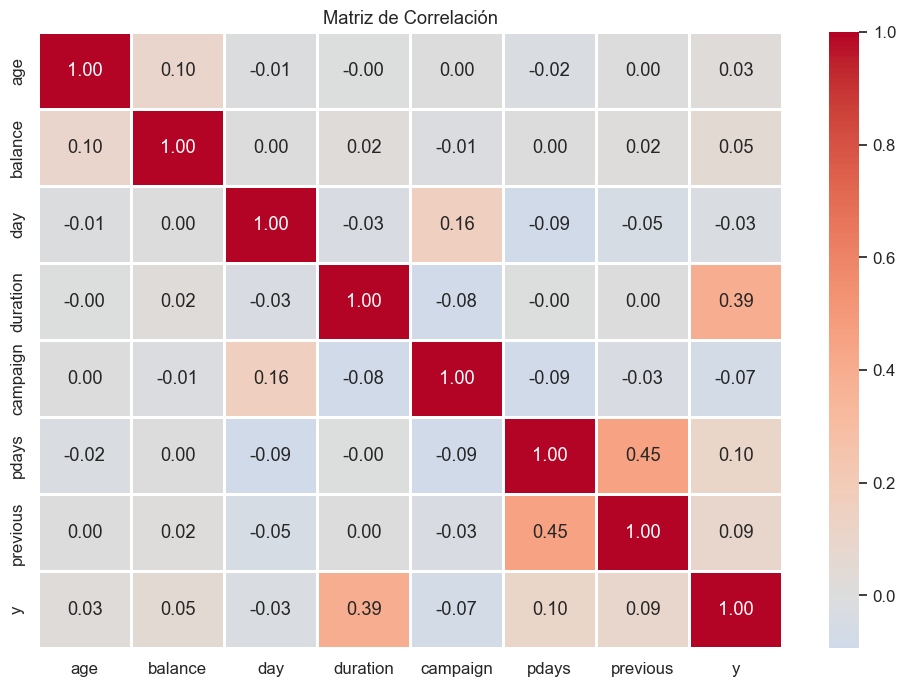

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selección de variables numéricas para la matriz de correlación
numeric_vars = df.select_dtypes(include='number')

# Cálculo de la matriz de correlación
correlation_matrix = numeric_vars.corr()

# Configuración de la visualización
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, linewidths=1, linecolor='white', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()



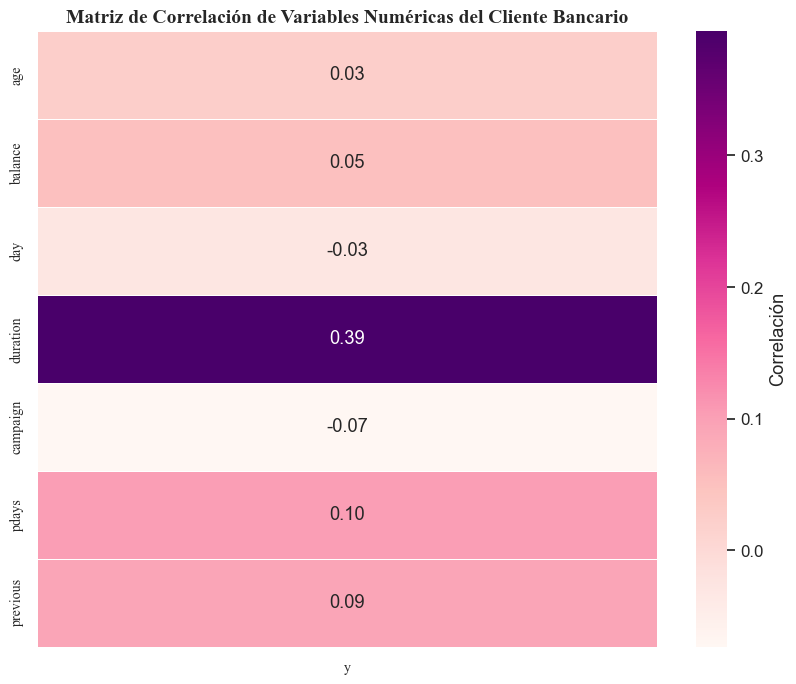

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selección de las variables numéricas
numeric_vars = ['age', 
                'balance', 
                'day', 
                'duration', 
                'campaign', 
                'pdays', 
                'previous']

# Calcular la matriz de correlación entre las variables numéricas
correlacion = df[numeric_vars + ['y']].corr()
# Filtrar para mostrar solo la correlación con la variable 'Rented Bike Count'
correlacion_interes = correlacion[['y']].drop('y')

# Crear un mapa de calor para visualizar la correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion_interes, annot=True, cmap='RdPu', fmt=".2f", linewidths=0.5, 
            cbar_kws={'label': 'Correlación'})
plt.title('Matriz de Correlación de Variables Numéricas del Cliente Bancario', 
          fontsize=14, fontweight='bold', family='Times New Roman')
plt.xticks(fontsize=10, family='Times New Roman')
plt.yticks(fontsize=10, family='Times New Roman')
plt.show()


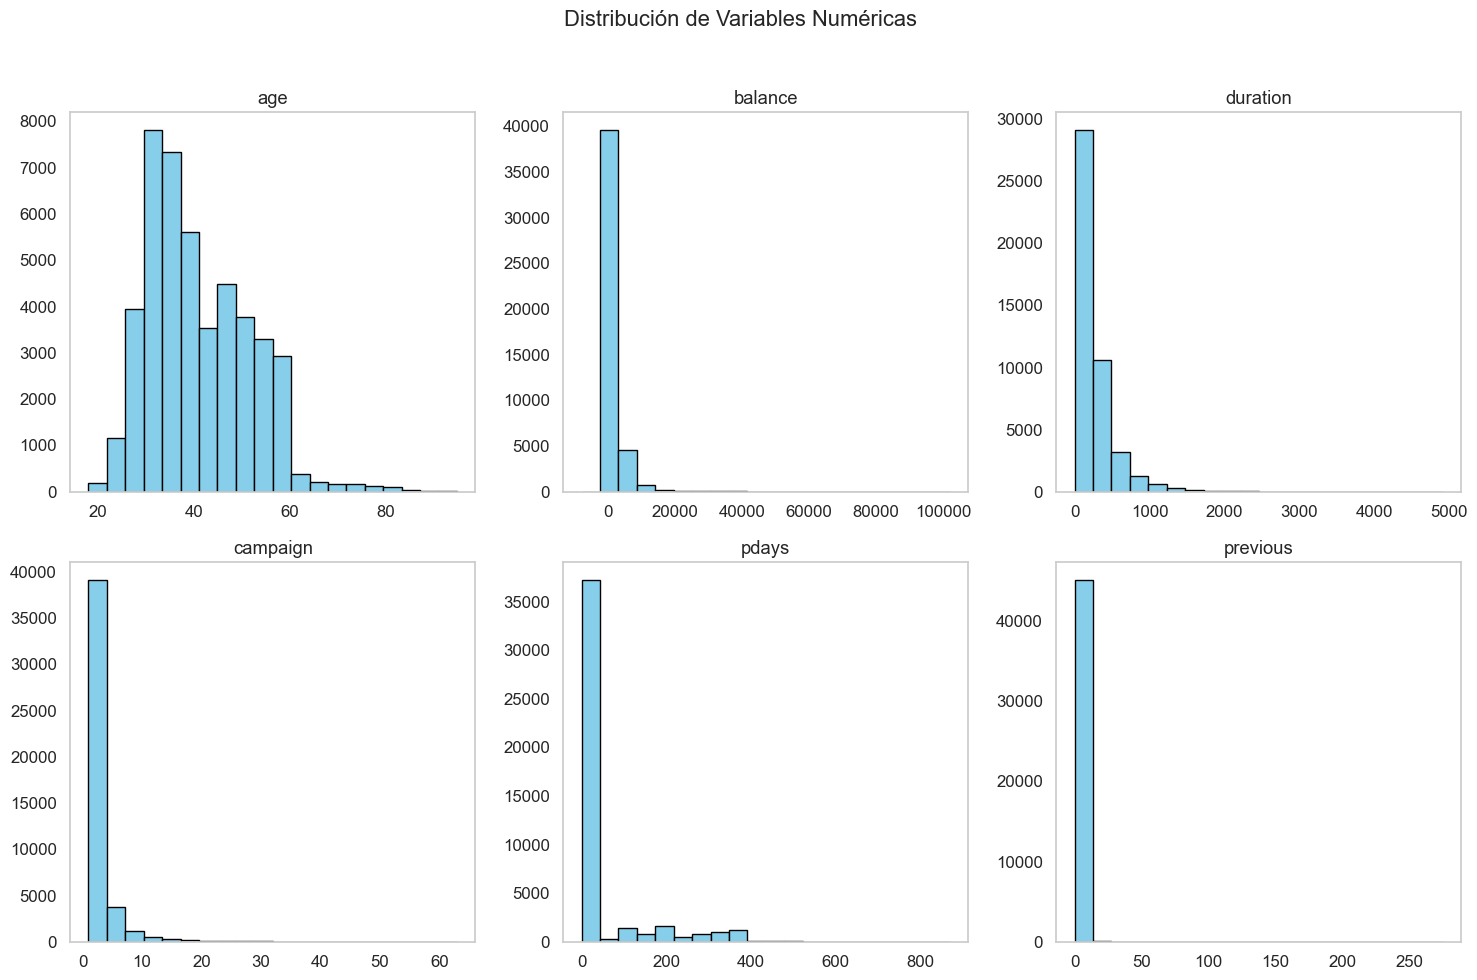

In [22]:
variables = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
df[variables].hist(bins=20, color='skyblue', edgecolor='black', grid=False, layout=(2, 3), figsize=(15, 10))
plt.suptitle("Distribución de Variables Numéricas")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


C:\Users\aleja\AppData\Local\Temp\ipykernel_138156\3548088416.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='balance', palette="viridis")


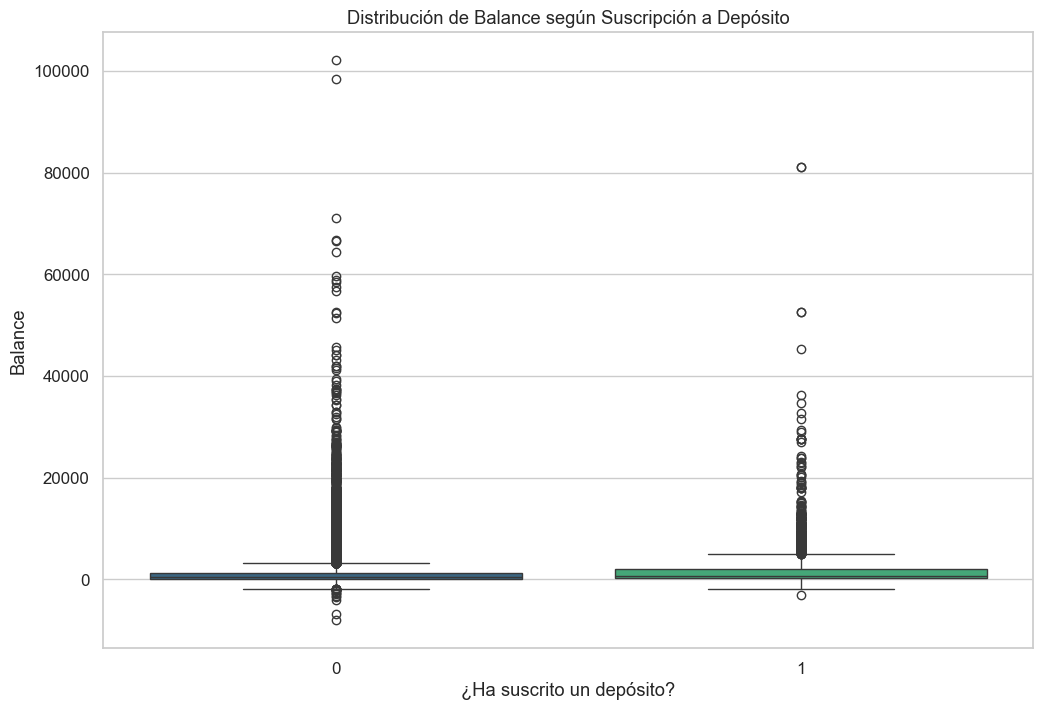

In [23]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='y', y='balance', palette="viridis")
plt.title("Distribución de Balance según Suscripción a Depósito")
plt.xlabel("¿Ha suscrito un depósito?")
plt.ylabel("Balance")
plt.show()


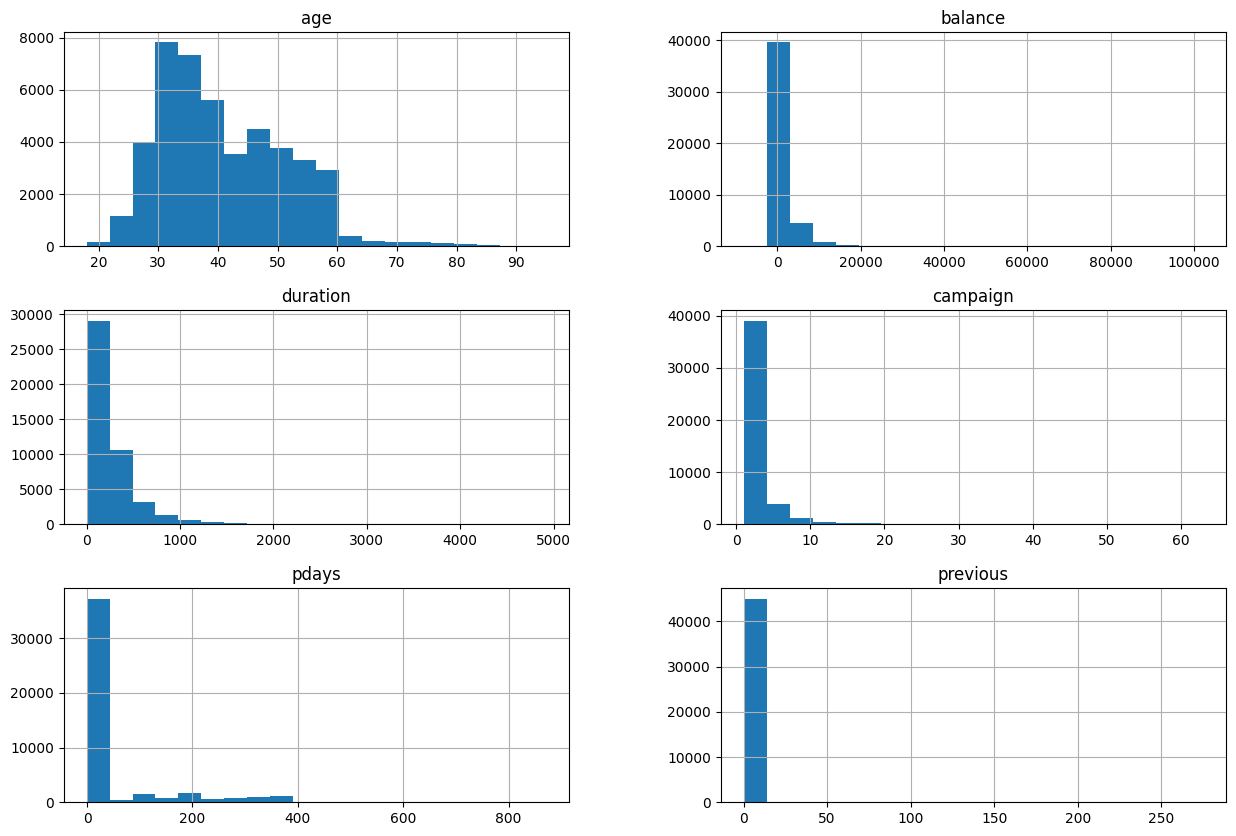

In [15]:
import matplotlib.pyplot as plt
df[['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']].hist(bins=20, figsize=(15, 10))
plt.show()


<Axes: xlabel='y', ylabel='balance'>

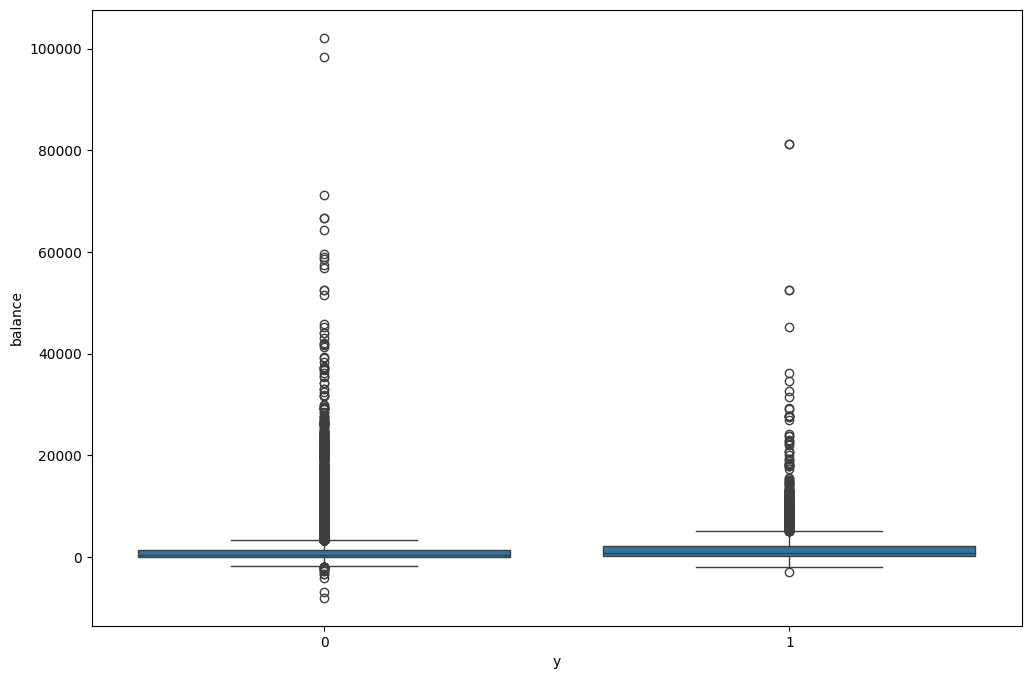

In [16]:
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='y', y='balance')


C:\Users\aleja\AppData\Local\Temp\ipykernel_138156\2477282007.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='y', y='duration', palette="coolwarm")


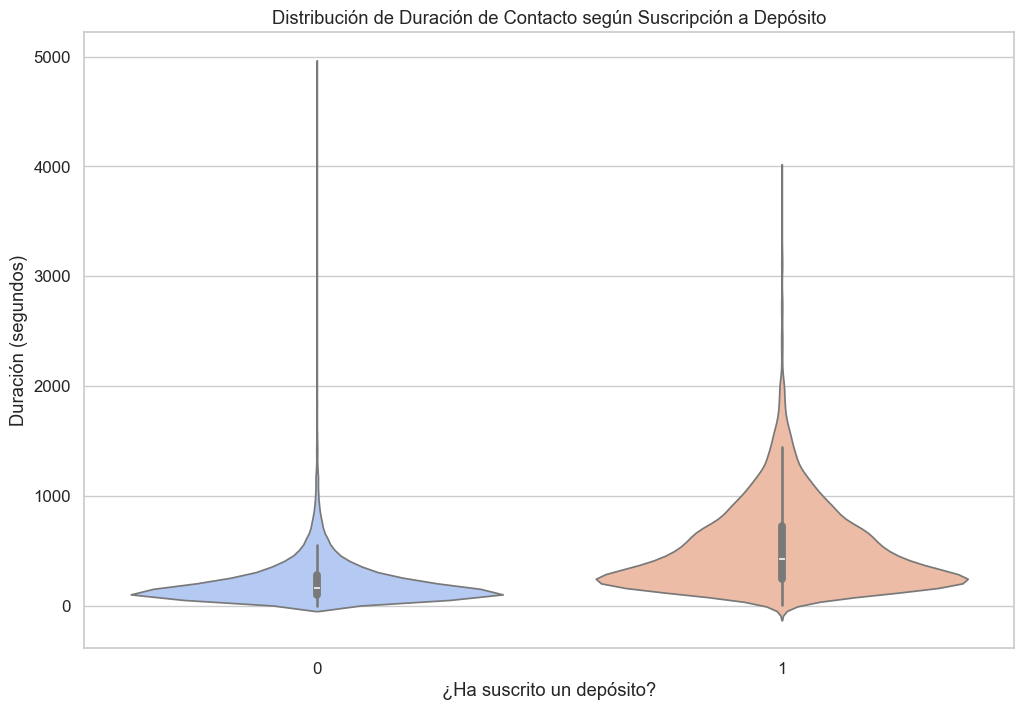

In [24]:
plt.figure(figsize=(12, 8))
sns.violinplot(data=df, x='y', y='duration', palette="coolwarm")
plt.title("Distribución de Duración de Contacto según Suscripción a Depósito")
plt.xlabel("¿Ha suscrito un depósito?")
plt.ylabel("Duración (segundos)")
plt.show()



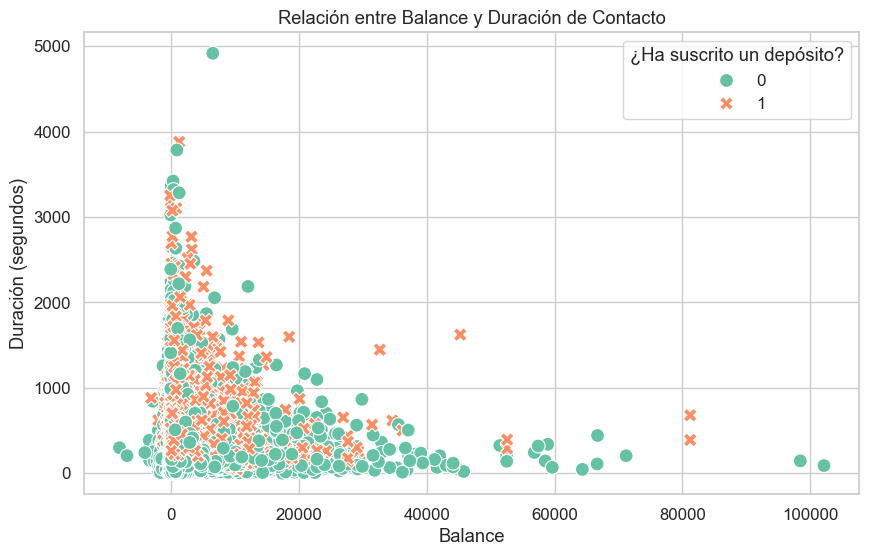

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='balance', y='duration', hue='y', style='y', palette="Set2", s=100)
plt.title("Relación entre Balance y Duración de Contacto")
plt.xlabel("Balance")
plt.ylabel("Duración (segundos)")
plt.legend(title="¿Ha suscrito un depósito?", loc="upper right")
plt.show()


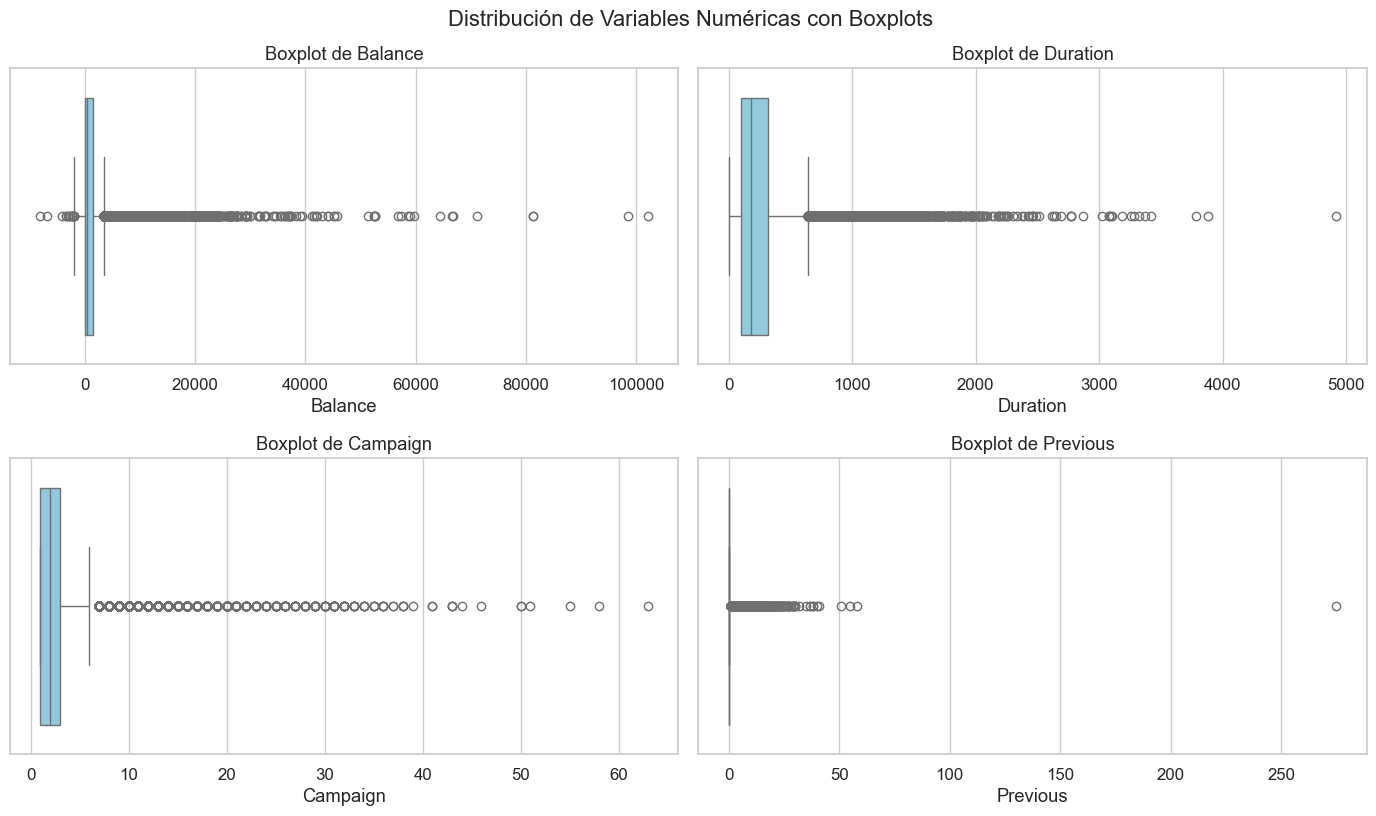

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set(style="whitegrid", palette="pastel", font_scale=1.1)
plt.figure(figsize=(14, 8))

# Selección de variables para boxplots
variables = ['balance', 'duration', 'campaign', 'previous']

# Gráfico de boxplot para múltiples variables numéricas
for i, var in enumerate(variables, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[var], color="skyblue")
    plt.title(f"Boxplot de {var.capitalize()}")
    plt.xlabel(var.capitalize())

plt.tight_layout()
plt.suptitle("Distribución de Variables Numéricas con Boxplots", y=1.02)
plt.show()



<Axes: xlabel='job'>

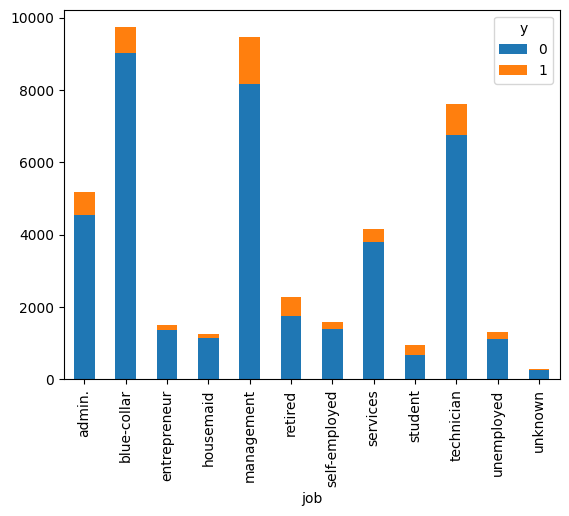

In [19]:
df.groupby(['job', 'y']).size().unstack().plot(kind='bar', stacked=True)
